In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# 1. CSV'yi oku
df = pd.read_csv("data/hospital_data.csv")

# 2. Excel olarak kaydet
df.to_excel("data/hospital_data.xlsx", index=False)

print("Dosya başarıyla Excel formatına çevrildi!")

Dosya başarıyla Excel formatına çevrildi!


In [ ]:
import pandas as pd

# Excel dosyasını oku
df = pd.read_excel("data/hospital_data.xlsx")

# 1- Sütun isimlerini ve veri tipleri neler 
print("--- Veri Seti Sütunları ---")
print(df.columns.tolist())

# 2- İlk 5 satırı inceleyebilelim
display(df.head())

# 3- Kaç satır ve kaç sütunumuz var?
print(f"\nVeri seti {df.shape[0]} satır ve {df.shape[1]} sütundan oluşuyor.")

--- Veri Seti Sütunları ---
['Month', 'Case_No', 'DOB', 'Nationality', 'Gender', 'DoctorLicense', 'DoctorName', 'Doctor Type', 'Doctor Status', 'CMI Value', 'Specialty', 'Insurance/Payer', 'InsurancePlanName', 'Payer Mix', 'Case type', 'LOS', 'Severity', 'Surgical Mix', 'Discharge Time', 'Discharge Before 12PM', 'Revenue']


,Month,Case_No,DOB,Nationality,Gender,DoctorLicense,DoctorName,Doctor Type,Doctor Status,CMI Value,...,Insurance/Payer,InsurancePlanName,Payer Mix,Case type,LOS,Severity,Surgical Mix,Discharge Time,Discharge Before 12PM,Revenue
0,2025-02-01,123517868,2002,Pakistan,F,ABC123,Dr. Shawn Martin,Consultant,Inactive,1.048,...,PureWin Insurance,Premium,Insurance,OP,0,1,Medical,07:00:00,Yes,548
1,2025-10-01,123810649,1981,Indonesia,F,VBN123,Dr. Peter Novak,Consultant,Active,0.942,...,PureWin Insurance,Basic,Insurance,OP,0,2,Medical,NaN,NaN,1198
2,2025-08-01,123979661,1990,Egypt,M,FGH123,Dr. Sofia Kim,GP,Active,1.089,...,PureWin Insurance,Premium,Insurance,OP,0,1,Medical,NaN,NaN,586
3,2025-06-01,123927914,1991,Germany,M,HJK123,Dr. Priya Iyer,Specialist,Active,0.970,...,BlueMedic Charity,NaN,Corporate,IP,5,1,Medical,09:13:00,Yes,28717
4,2025-06-01,123605097,2000,UAE,F,ABC234,Dr. Thomas Muller,Specialist,Active,1.006,...,Nextcare Insurance,NC-Blue,Insurance,IP,4,3,Medical,13:39:00,No,117129



Veri seti 500 satır ve 21 sütundan oluşuyor.


In [3]:
# 1- Eksik veri kontrolü
print("--- Eksik Veri Sayıları ---")
print(df.isnull().sum())

# 2- Tekrar eden satır kontrolü
print(f"\nTekrar eden satır sayısı: {df.duplicated().sum()}")

# 3- Veri tiplerini kontrol et (int, float, object) doğru mu?
print("\n--- Veri Tipleri ---")
print(df.dtypes)

--- Eksik Veri Sayıları ---
Month                      0
Case_No                    0
DOB                        0
Nationality                0
Gender                     0
DoctorLicense              0
DoctorName                 0
Doctor Type                0
Doctor Status              0
CMI Value                  0
Specialty                  0
Insurance/Payer            0
InsurancePlanName         72
Payer Mix                  0
Case type                  0
LOS                        0
Severity                   0
Surgical Mix               0
Discharge Time           238
Discharge Before 12PM    238
Revenue                    0
dtype: int64

Tekrar eden satır sayısı: 0

--- Veri Tipleri ---
Month                     object
Case_No                    int64
DOB                        int64
Nationality               object
Gender                    object
DoctorLicense             object
DoctorName                object
Doctor Type               object
Doctor Status             object
CM

In [4]:
# 1: InsurancePlanName, Discharge Before 12PM NaN varsa "Not Specified" (Belirtilmemiş) yapalım
df['InsurancePlanName'] = df['InsurancePlanName'].fillna('Not Specified')
df['Discharge Before 12PM'] = df['Discharge Before 12PM'].fillna('Not Specified')

# 2. Veri Tipi Düzeltme (Object -> Datetime)
# saat formatına çevir 
df['Discharge Time'] = pd.to_datetime(df['Discharge Time'], errors='coerce')

# 3:(Outlier) ve yazım kontrolü başta sonda boşluklar var mı?
# Cinsiyet veya Vaka Tipi gibi sütunlarda gereksiz boşlukları temizleyelim
df['Gender'] = df['Gender'].str.strip()
df['Case type'] = df['Case type'].str.strip()

# 4: Son kontrol tekrar yazdır hepsi 0 mı?
print("--- Temizlik Sonrası Eksik Veri Durumu ---")
print(df.isnull().sum())
print("\n--- Veri Tipleri Son Durum ---")
print(df.dtypes[['Discharge Time', 'InsurancePlanName']])

--- Temizlik Sonrası Eksik Veri Durumu ---
Month                      0
Case_No                    0
DOB                        0
Nationality                0
Gender                     0
DoctorLicense              0
DoctorName                 0
Doctor Type                0
Doctor Status              0
CMI Value                  0
Specialty                  0
Insurance/Payer            0
InsurancePlanName          0
Payer Mix                  0
Case type                  0
LOS                        0
Severity                   0
Surgical Mix               0
Discharge Time           238
Discharge Before 12PM      0
Revenue                    0
dtype: int64

--- Veri Tipleri Son Durum ---
Discharge Time       datetime64[ns]
InsurancePlanName            object
dtype: object


/var/folders/rj/bcqqrkgd35v4rzj3c1w99r540000gn/T/ipykernel_99014/71762598.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Discharge Time'] = pd.to_datetime(df['Discharge Time'], errors='coerce')


In [ ]:
#  Genel İstatistik Tablosu
stats_summary = df[['Revenue', 'LOS', 'CMI Value']].describe().T
print("--- HASTANE GENEL PERFORMANS TABLOSU ---")
print(stats_summary[['mean', '50%', 'std', 'min', 'max']])

--- HASTANE GENEL PERFORMANS TABLOSU ---
                   mean       50%           std    min         max
Revenue    17046.728000  1628.500  30527.293520  99.00  160962.000
LOS            1.284000     0.000      1.946000   0.00       7.000
CMI Value      1.037098     1.035      0.110963   0.71       1.394


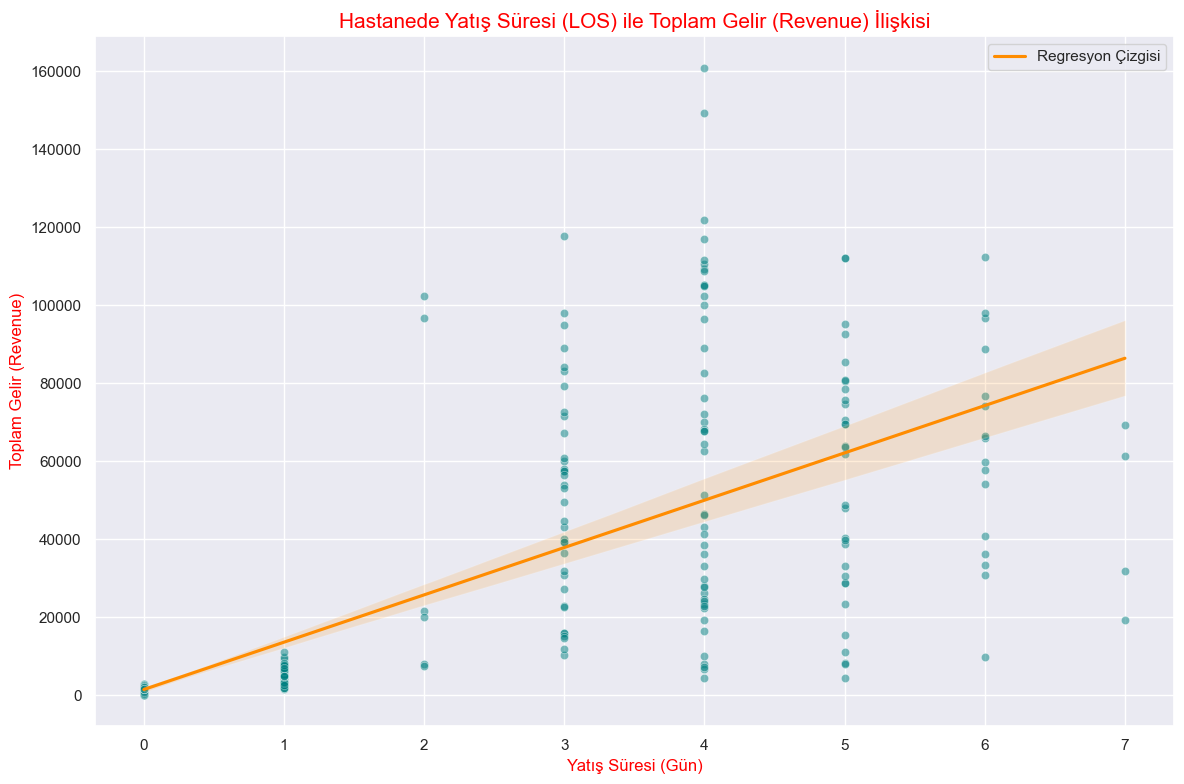

LOS ve Revenue arasındaki Korelasyon Katsayısı (Pearson): 0.77


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid") # grafik stili
plt.figure(figsize=(12, 8)) # LOS ve Reveneu ilişki analizi
sns.scatterplot(data=df, x='LOS', y='Revenue', alpha=0.5, color='teal') # Scatter plot oluştur
sns.regplot(data=df, x='LOS', y='Revenue', scatter=False, color='darkorange', label='Regresyon Çizgisi') # Grafik üzeri regresyon çizgisi

plt.title('Hastanede Yatış Süresi (LOS) ile Toplam Gelir (Revenue) İlişkisi', fontsize=15, color='red')
plt.xlabel('Yatış Süresi (Gün)', fontsize=12, color='red')
plt.ylabel('Toplam Gelir (Revenue)', fontsize=12, color='red')
plt.legend()

plt.tight_layout()
plt.show()

# Korelasyon Katsayısı (-1 ile 1 arası değerler alır, +1e yakın olduğunda aynı oranla artıyor -1 ise negatif ilişki 0 ise alakasız davranıyorlar    )
correlation = df['LOS'].corr(df['Revenue'])
print(f"LOS ve Revenue arasındaki Korelasyon Katsayısı (Pearson): {correlation:.2f}")

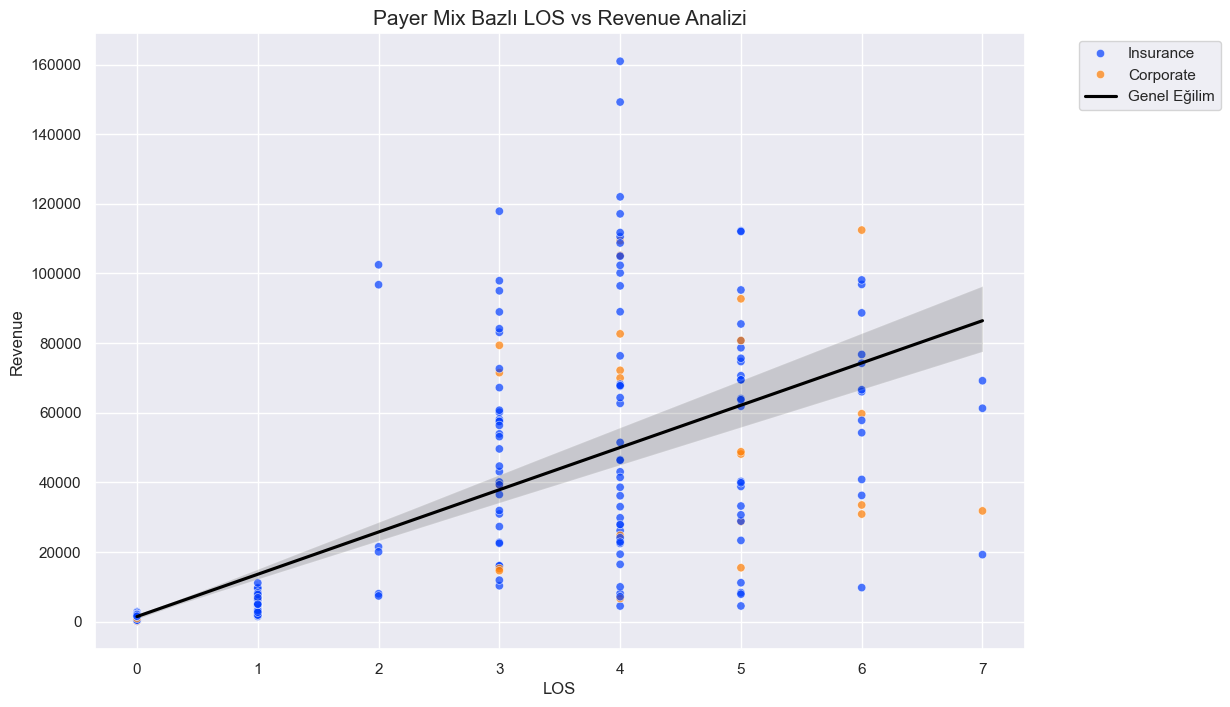

In [ ]:
#Payer Mix Bazlı LOS vs Revenue Analizi(hangi sigorta türünde daha fazla gelir elde ediliyor)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='LOS', y='Revenue', hue='Payer Mix', alpha=0.7, palette='bright') #hue='Payer Mix' noktaları sigorta türüne göre renklendir
sns.regplot(data=df, x='LOS', y='Revenue', scatter=False, color='black', label='Genel Eğilim')
plt.title('Payer Mix Bazlı LOS vs Revenue Analizi', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Efsaneyi (legend) dışarı alalım
plt.show()

In [13]:
#Anomali 10 vaka tespit etmek için (Residual Analysis -pozitif çizgi üstü beklenenden karlı, negatif çizgi altı beklenenden zararlı)
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

#Regresyon modeli oluştur(beklentileri tahmin etmek için)
X = df[['LOS']].values
y = df['Revenue'].values
model = LinearRegression().fit(X, y)

df['Expected_Revenue'] = model.predict(X) #her hasta için tahmin
df['Deviation'] = df['Revenue'] - df['Expected_Revenue'] #gerçek-tahmin

top_10_anomalies = df.reindex(df.Deviation.abs().sort_values(ascending=False).index).head(10) #en çok sapan 10 vaka (mutlak değer)

print("\n--- OLASI ANOMALİ İÇİN İNCELENMESİ GEREKEN 10 KRİTİK VAKA ---\n")
cols_to_show = ['Case_No', 'Specialty', 'DoctorName', 'Payer Mix', 'LOS', 'Revenue', 'Deviation']
print(top_10_anomalies[cols_to_show])


--- OLASI ANOMALİ İÇİN İNCELENMESİ GEREKEN 10 KRİTİK VAKA ---

       Case_No         Specialty         DoctorName  Payer Mix  LOS  Revenue  \
171  123790221   General Surgery    Dr. Hana Suzuki  Insurance    4   160962   
421  123767392         Emergency   Dr. Shawn Martin  Insurance    4   149242   
342  123950732   General Surgery    Dr. Hana Suzuki  Insurance    3   117884   
331  123587010   General Surgery    Dr. Hana Suzuki  Insurance    2   102497   
163  123566107        Nephrology  Dr. Thomas Muller  Insurance    4   122019   
60   123747862       Pulmonology   Dr. Aisha Rahman  Insurance    2    96767   
401  123479038  Gastroenterology    Dr. Ahmed Zayed  Insurance    7    19233   
4    123605097        Nephrology  Dr. Thomas Muller  Insurance    4   117129   
88   123911398   General Surgery    Dr. Hana Suzuki  Insurance    6     9763   
272  123458660  Gastroenterology    Dr. Ahmed Zayed  Insurance    4   111745   

         Deviation  
171  110945.654266  
421   99225.6

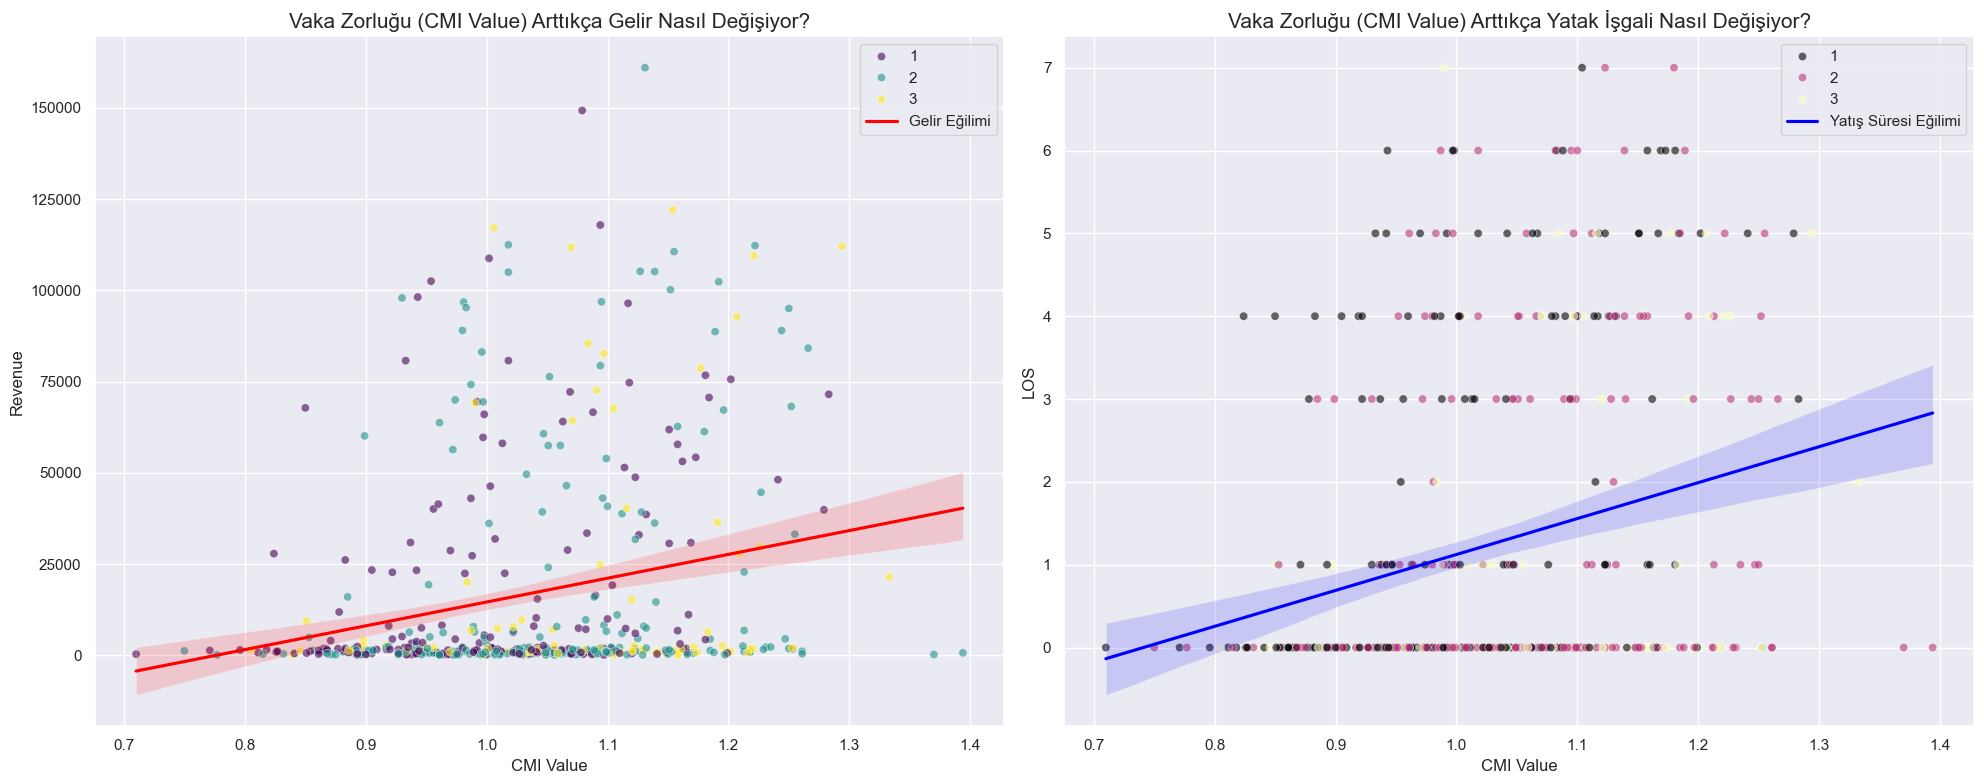

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8)) #1 satır 2 sütunluk grafik

# 1. GRAFİK: CMI vs Revenue 
sns.scatterplot(ax=axes[0], data=df, x='CMI Value', y='Revenue', hue='Severity', palette='viridis', alpha=0.6)
sns.regplot(ax=axes[0], data=df, x='CMI Value', y='Revenue', scatter=False, color='red', label='Gelir Eğilimi')
axes[0].set_title('Vaka Zorluğu (CMI Value) Arttıkça Gelir Nasıl Değişiyor?', fontsize=15)
axes[0].legend()

# 2. GRAFİK: CMI vs LOS 
sns.scatterplot(ax=axes[1], data=df, x='CMI Value', y='LOS', hue='Severity', palette='magma', alpha=0.6)
sns.regplot(ax=axes[1], data=df, x='CMI Value', y='LOS', scatter=False, color='blue', label='Yatış Süresi Eğilimi')
axes[1].set_title('Vaka Zorluğu (CMI Value) Arttıkça Yatak İşgali Nasıl Değişiyor?', fontsize=15)
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/rj/bcqqrkgd35v4rzj3c1w99r540000gn/T/ipykernel_99014/333468329.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Specialty', y='Daily_Revenue', palette='coolwarm', errorbar=None)#barplot ile ortalama verimlilik


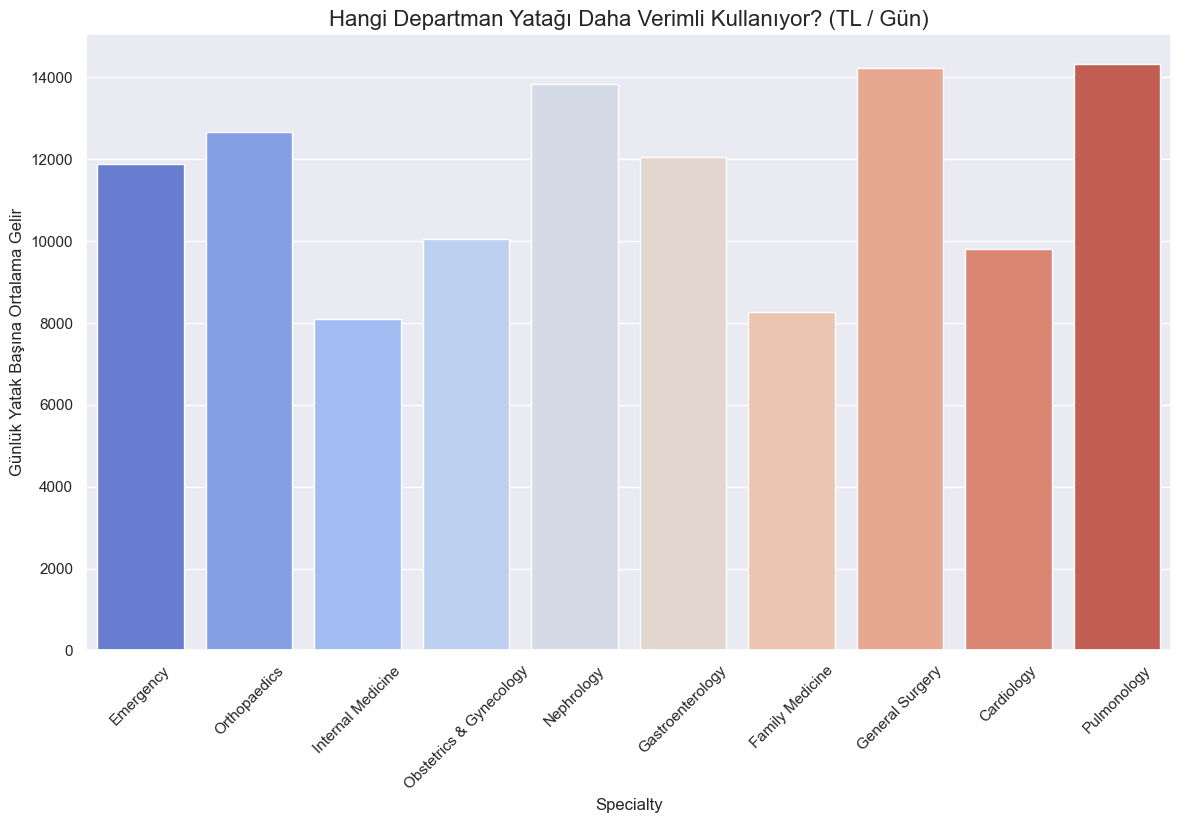

In [33]:
#Verimlilik 
df['Daily_Revenue'] = df['Revenue'] / df['LOS']
plt.figure(figsize=(14, 8)) #departman bazlı verimlilik
sns.barplot(data=df, x='Specialty', y='Daily_Revenue', palette='coolwarm', errorbar=None)#barplot ile ortalama verimlilik

plt.title('Hangi Departman Yatağı Daha Verimli Kullanıyor? (TL / Gün)', fontsize=16)
plt.ylabel('Günlük Yatak Başına Ortalama Gelir')
plt.xticks(rotation=45)
plt.show()

In [35]:
#Feature Engineering(Scaling-sayısalları normalleştirmek 0 ile 1 arasına çekmek içiniçin,Encoding-kategorik değişkenleri sayısal yapmak için)
import pandas as pd
from sklearn.preprocessing import StandardScaler

#Analizde kullanılacak sütunlar
selected_features = ['Revenue', 'LOS', 'CMI Value', 'Payer Mix', 'Specialty']
df_final = df[selected_features].copy()

#Encoding (one-hot encoding(0-1-2-3 değerleri yok, 1 ve 0 ))
df_encoded = pd.get_dummies(df_final, columns=['Payer Mix', 'Specialty'])

#Scaling
scaler = StandardScaler()
numeric_cols = ['Revenue', 'LOS', 'CMI Value']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
print("Encoding ve Scaling uygulandı. Veri seti yapay zeka dilinde.")
df_encoded.head()

Encoding ve Scaling uygulandı. Veri seti yapay zeka dilinde.


,Revenue,LOS,CMI Value,Payer Mix_Corporate,Payer Mix_Insurance,Specialty_Cardiology,Specialty_Emergency,Specialty_Family Medicine,Specialty_Gastroenterology,Specialty_General Surgery,Specialty_Internal Medicine,Specialty_Nephrology,Specialty_Obstetrics & Gynecology,Specialty_Orthopaedics,Specialty_Pulmonology
0,-0.541000,-0.660476,0.098348,False,True,False,True,False,False,False,False,False,False,False,False
1,-0.519686,-0.660476,-0.857884,False,True,False,False,False,False,False,False,False,False,True,False
2,-0.539753,-0.660476,0.468211,False,True,False,False,False,False,False,True,False,False,False,False
3,0.382673,1.911470,-0.605295,True,False,False,False,False,False,False,False,False,True,False,False
4,3.281736,1.397081,-0.280537,False,True,False,False,False,False,False,False,True,False,False,False


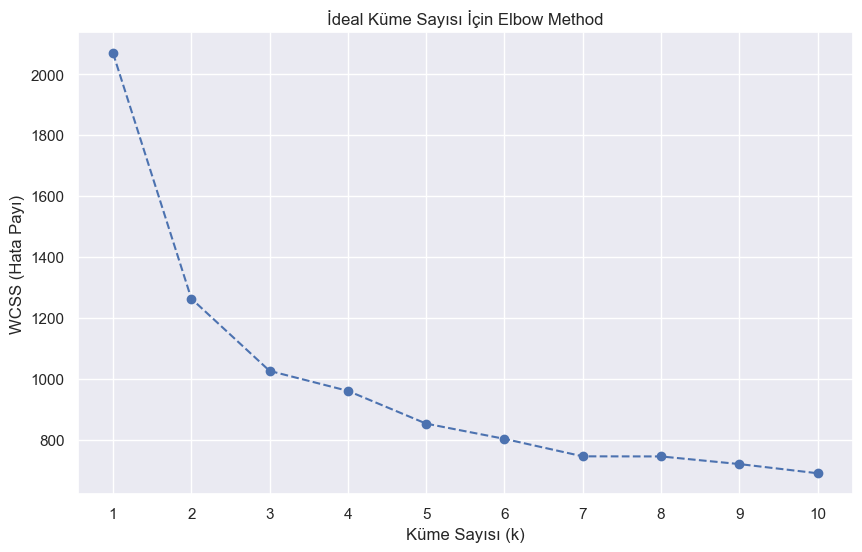

In [ ]:
#  KMeans Clustering
#  1-Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] #hata paylarını(WCSS) saklamak için liste

for i in range(1, 11): #1'den 10'a kadar küme sayılarını dene
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_encoded)
    wcss.append(kmeans.inertia_)

#Elbow Method grafiği çiz
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('İdeal Küme Sayısı İçin Elbow Method')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('WCSS (Hata Payı)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()





In [43]:
# Modeli 3 küme ile çalıştır
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_encoded) #Hastaları gruplarına ayır
df['Cluster'] = clusters

#Kümelerin ortalama verimliliklerini incele
analysis = df.groupby('Cluster').agg({
    'Revenue': 'mean',
    'LOS': 'mean',
    'CMI Value': 'mean'
}).rename(columns={
    'Revenue': 'Ortalama Gelir',
    'LOS': 'Ortalama Yatış Süresi',
    'CMI Value': 'Ortalama Vaka Zorluğu'
})

print("--- KÜME BAZLI STRATEJİK ANALİZ SONUÇLARI ---")
display(analysis)




--- KÜME BAZLI STRATEJİK ANALİZ SONUÇLARI ---


,Ortalama Gelir,Ortalama Yatış Süresi,Ortalama Vaka Zorluğu
Cluster,,,
0,2563.18,0.32,0.93
1,2106.71,0.22,1.11
2,61623.52,4.35,1.09


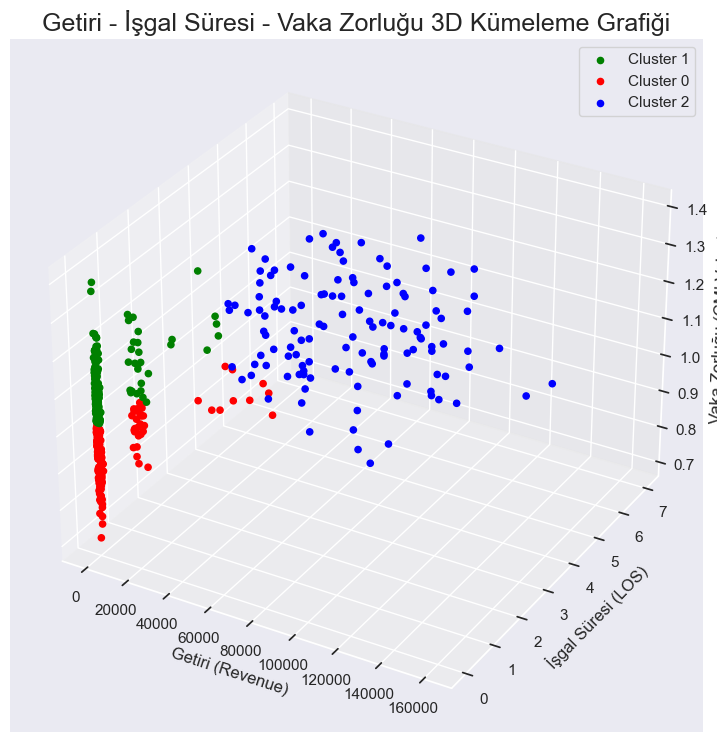

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grafik Alanını Oluşturma
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue'] 

# Scatter Plot ile 3 boyutlu dağılım
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    ax.scatter(subset['Revenue'], subset['LOS'], subset['CMI Value'], 
               c=colors[cluster], label=f'Cluster {cluster}', alpha=1, s=20)

# X,Y,Z eksenleri, başlık 
ax.set_xlabel('Getiri (Revenue)')
ax.set_ylabel('İşgal Süresi (LOS)')
ax.set_zlabel('Vaka Zorluğu (CMI Value)')
ax.set_title('Getiri - İşgal Süresi - Vaka Zorluğu 3D Kümeleme Grafiği', fontsize=18)
ax.legend()
plt.show()